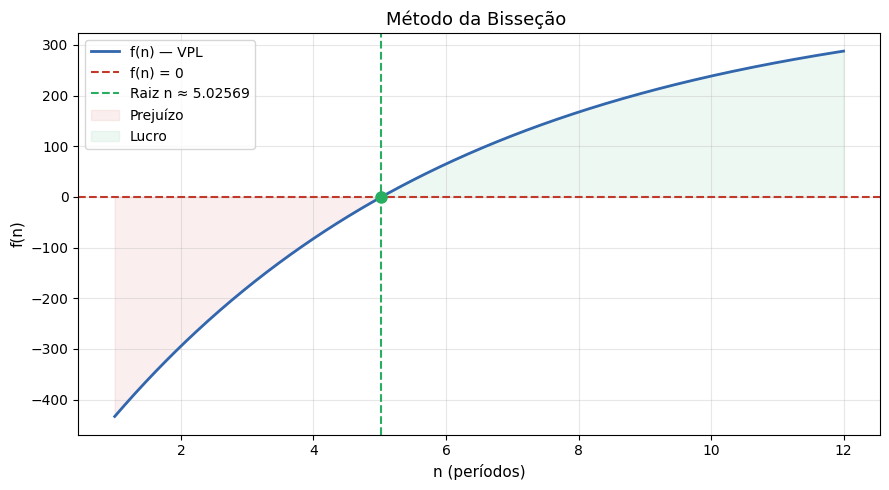

Raiz encontrada:  n = 5.02569
Iterações:            23
Erro final:           2.11e-06


In [12]:
import math
import matplotlib.pyplot as plt
import numpy as np

def f(n):
    return -600 + 200 * ((1.2**n - 1) / (0.2 * 1.2**n))

def bissecao(f, a, b, epsilon=1e-5, max_iter=100):
    if f(a) * f(b) >= 0:
        print("Intervalo inválido!")
        return None
    iteracoes = 0
    erros = []
    while iteracoes < max_iter:
        m = (a + b) / 2
        erro = abs(f(m))
        erros.append(erro)
        if erro < epsilon:
            return m, iteracoes, erro, erros
        if f(a) * f(m) < 0:
            b = m
        else:
            a = m
        iteracoes += 1
    return m, iteracoes, abs(f(m)), erros

raiz, iteracoes, erro, erros = bissecao(f, 3, 10)

n_vals = np.linspace(1, 12, 500)
f_vals = [f(n) for n in n_vals]

plt.figure(figsize=(9, 5))
plt.plot(n_vals, f_vals, color="#3266ad", linewidth=2, label="f(n) — VPL")
plt.axhline(0, color="#c0392b", linewidth=1.5, linestyle="--", label="f(n) = 0")
plt.axvline(raiz, color="#27ae60", linewidth=1.5, linestyle="--", label=f"Raiz n ≈ {raiz:.5f}")
plt.plot(raiz, f(raiz), "o", color="#27ae60", markersize=8, zorder=5)
plt.fill_between(n_vals, f_vals, 0, where=[v < 0 for v in f_vals], alpha=0.08, color="#c0392b", label="Prejuízo")
plt.fill_between(n_vals, f_vals, 0, where=[v > 0 for v in f_vals], alpha=0.08, color="#27ae60", label="Lucro")
plt.xlabel("n (períodos)", fontsize=11)
plt.ylabel("f(n)", fontsize=11)
plt.title("Método da Bisseção ", fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Raiz encontrada:  n = {raiz:.5f}")
print(f"Iterações:            {iteracoes}")
print(f"Erro final:           {erro:.2e}")